<div class="alert alert-block alert-info" >
    <h1>Machine Learning: Assignment 6 (Last assignment)</h1>
    <h2>This is a two week assignment</h2>
    <h3>General Information:</h3>
    <p>Feel free to add cells if required.<br> Feel free to write your own function block to reduce the redundancy.<br> Answers belong into the corresponding cells (below the question). <br><br> If you encounter empty cells underneath the answer that can not be edited, please ignore them, they are for testing purposes.<br><br>When editing an assignment there can be the case that there are variables in the kernel. To make sure your assignment works, please restart the kernel and run all cells before submitting (e.g. via <i>Kernel -> Restart & Run All</i>). We don't consider that respective solution if you make this mistake (no excuse).</p>
    <br><br><b> Plot should have axis labels, grid, legend, title, atleast size 10X10 also give proper comments, function name, variable names to your coding, if you didn't follow the instructions there will be a reduction in the points.</b><br><br>
     <br><br><b> Write sudo-code if you didn't get output or left out of time so that you will be awarded with atmost 50% of marks for that particular session.</b><br><br>
    <h3>Submission:</h3>
    <p>Use the following naming convention for your submissions: LA_FirstnameLastname_dateOfLecture, e.g LA_JohnDoe_YYMMDD
     <br><br>Please submit your notebook via LEA. The assignment is due on <b>$23^{th}$ January, Saturday at 20:00.</b> </p>
    <h3>Group Work:</h3>
    <p>You are allowed to work in groups of up to two people. Please enter the UID (your username here) of each member of the group into the next cell. We apply plagiarism checking, so do not submit solutions from other people except your team members. If an assignment has a copied solution, the task will be graded with 0 points for all people with the same solution.</p>
    <p><b>YOU SHOULD ONLY SUBMIT EXACTLY ONE PER GROUP</b></p>
    <h3>Questions about the Assignment:</h3>
    <p>If you have questions about the assignment please post them in the LEA forum before the deadline. Don't wait until the last day to post questions.</p></div>

In [ ]:
'''
Group Work:
Enter the UID (i.e. student2s) of each team member into the variables.
If you work alone please leave the second variable empty, or extend the list if necessary.
'''
member1 = 'g_vrammo2s'
member2 = ''

# Neural Networks  [100 points]

### Implement a neural network to recognize handwritten digits from MNIST dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import multilabel_confusion_matrix
from sklearn.preprocessing import OneHotEncoder
import sklearn.preprocessing as preprocessing
from sklearn.metrics import confusion_matrix, accuracy_score

import time

from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from keras.datasets import mnist

## Task 1: Data Visualization [20 points]


### Visualize the dataset as a image refer the attached file handwritten.png

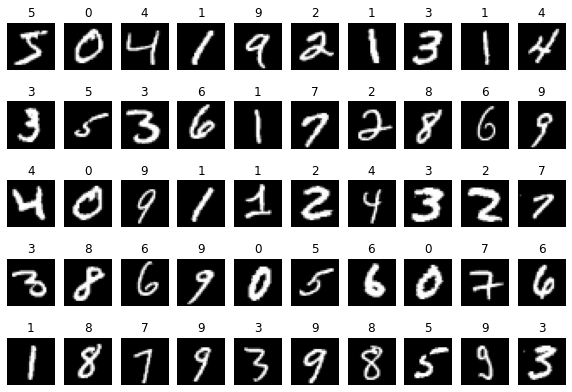

In [ ]:
# Import the mnist dataset from Keras
(x_train, y_train), (x_test, y_test) = mnist.load_data()

#visualize the dataset
plt.figure(figsize = (10,7))

num_images = 50
for i in range(num_images):
    row = x_train[i]
    label = y_train[i]

    image = row

    plt.subplot(5, 10, i+1)
    plt.title(label)
    plt.axis('off')

    plt.imshow(image, cmap='gray')

## Task 2: Construct a network of 3 layers own implementation [50 points]

### Layer structure
- An input layer (since image has size 28x28 you will have 784 input nodes, other source can have 20x20 in that case it is 400)

- A hidden layer with 25 nodes

- An output layer with 10 classes (corresponding to the 10 digits)

- Implement (from scratch) feedforward propagation for this neural network to predict handwritten digits

- Implement (from scratch) the backpropagation algorithm to learn the parameters for the network. Use cross-entropy loss function without regularization.

### Hyperparameters

- Loss function - Cross-entropy without regularization
- Learning method - Stochastic Gradient Descent
- Metrics - Accuracy
- Activation method - relu/sigmoid for hidden layer; softmax for output layer
- Batch size - 128
- Epochs- 50

### Output

- Accuracy
- Confusion matrix

**Note:** For the simplicity recode the labels as vectors containing only values 0 or 1 (One hot encoding).

** used various sources I got inspired by to do this assignment **

In [ ]:
input_units = 784
batch_size = 128
epochs = 50
num_classes = 10

In [ ]:
x_test.shape

(10000, 28, 28)

In [ ]:
# Normalize

x_train = (x_train.astype("float32")/ 255)
x_test = (x_test.astype("float32")/ 255)

In [ ]:
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

y_train = tf.one_hot(y_train,10)
y_test = tf.one_hot(y_test,10)

y_train = y_train.numpy()
y_test = y_test.numpy()

In [ ]:
y_test.shape

(10000, 10)

In [ ]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

# Define network structure
n_y = y_train.shape[1]

width = [input_units, 25, n_y]

In [ ]:
# Define activation functions

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def softmax(x):
    return np.exp(x) / np.sum(np.exp(x), axis = -1).reshape(x.shape[0], 1)

def relu(x):
    return np.maximum(0,x)

In [ ]:
# Compute loss

def crossentropy_loss(y, b, w):

    m = y.shape[0]

    output,Z = forward_propagation(x_train, b, w)

    final_output = output[-1]
    logprobs = np.log(final_output) * y

    loss = -np.sum(logprobs)/m

    count = 0
    for i in range(final_output.shape[0]):
        if (np.argmax(final_output[i,:]) == np.argmax(y[i,:])):
            count = count + 1

    loss = np.squeeze(loss)

    return loss, count

In [ ]:
# Initialize weights and biases

def initialize_parameters(width):

    weights = []
    biases = []

    for i in range(len(width) - 1):
        w = np.random.randn(width[i], width[i+1])
        b = np.zeros((width[i+1],))
        weights.append(w)
        biases.append(b)

    return biases, weights

In [ ]:
# Compute forward propagation

def forward_propagation(x, biases, weights):
    a = x
    output = [x]
    Z = [x]
    para = zip(weights,biases)

    for i,(w,b) in enumerate(para):
        z = np.dot(a,w) + b

#         Softmax for last layer
        if i == len(biases) - 1:
            a = softmax(z)
        else:
            a = sigmoid(z)
        Z.append(z)
        output.append(a)

    return output, Z

In [ ]:
# Compute backpropagation

def backward_propagation(x, y, biases, weights):

    output, Z = forward_propagation(x, biases, weights)
    m = x.shape[0]

    nlayers = len(biases)
    # Loss of the last layer
    dz = output[nlayers] - y

    gradb = []
    gradw = []

    for i in range(nlayers,0,-1):
        db = np.sum(dz,axis = 0, keepdims = True) / m
        dw = np.dot(output[i-1].T, dz) / m
        dz = np.dot(dz, weights[i-1].T) * output[i-1] * (1 - output[i-1])

        gradb.insert(0, db)
        gradw.insert(0, dw)

    return gradb, gradw

In [ ]:
# Update values of weights and biases

def update_parameters(biases, weights, gradb, gradw, learning_rate):

    for i in range(len(biases)):
        weights[i] = weights[i] - learning_rate * gradw[i]
        biases[i] = biases[i] - learning_rate * gradb[i]

    return biases, weights

In [ ]:
# Compute stochastic gradient descent

def gradient_descent(x, y, test_data, width, batch_size, num_iterations, learning_rate, print_cost = False):

    biases, weights = initialize_parameters(width)

    for i in range(0, num_iterations):
        cost, count = crossentropy_loss(y, biases, weights)

        for k in range(0, x.shape[0], batch_size):

            idx = [np.random.randint(0, y.shape[0] - 1) for s in range(batch_size)]
            yb = y[idx,:]
            xb = x[idx,:]

            gradb, gradw = backward_propagation(xb, yb, biases, weights)
            biases, weights = update_parameters(biases, weights, gradb, gradw, learning_rate)

        if i%1 == 0 :
            count = count / y.shape[0]
            print ("Epoch {}: cost = {:.2f}, train accuracy = {:.2f}".format(i, cost, count))

    return biases, weights

In [ ]:
# Compute gradient descent if needed

def gradientDescent(x, y, theta, alpha, num_iters):
    m = y.size

    for i in range(num_iters):
        y_hat = np.dot(x, theta)
        theta = theta - alpha * (1.0/m) * np.dot(x.T, y_hat - y)

    return theta

In [ ]:
# Train model and return weights and biases

start = time.time()

biases, weights = gradient_descent(x_train, y_train, x_test, width, batch_size = batch_size, learning_rate = 3, num_iterations = epochs, print_cost = True)

end = time.time()
time = (end - start)
print("Total time =", time, "s")

Epoch 0: cost = 6.14, train accuracy = 0.07
Epoch 1: cost = 0.35, train accuracy = 0.90
Epoch 2: cost = 0.28, train accuracy = 0.92
Epoch 3: cost = 0.23, train accuracy = 0.93
Epoch 4: cost = 0.21, train accuracy = 0.94
Epoch 5: cost = 0.19, train accuracy = 0.94
Epoch 6: cost = 0.17, train accuracy = 0.95
Epoch 7: cost = 0.17, train accuracy = 0.95
Epoch 8: cost = 0.16, train accuracy = 0.95
Epoch 9: cost = 0.15, train accuracy = 0.95
Epoch 10: cost = 0.14, train accuracy = 0.96
Epoch 11: cost = 0.14, train accuracy = 0.96
Epoch 12: cost = 0.13, train accuracy = 0.96
Epoch 13: cost = 0.13, train accuracy = 0.96
Epoch 14: cost = 0.12, train accuracy = 0.96
Epoch 15: cost = 0.12, train accuracy = 0.97
Epoch 16: cost = 0.11, train accuracy = 0.97
Epoch 17: cost = 0.11, train accuracy = 0.97
Epoch 18: cost = 0.11, train accuracy = 0.97
Epoch 19: cost = 0.10, train accuracy = 0.97
Epoch 20: cost = 0.10, train accuracy = 0.97
Epoch 21: cost = 0.10, train accuracy = 0.97
Epoch 22: cost = 0.1

In [ ]:
# Evaluate model

output, Z = forward_propagation(x_test, biases, weights)
final_output = output[-1]
count = 0
total = 0

for i in range(final_output.shape[0]):
    if np.argmax(final_output[i,:]) == y_test[i,0]:
        count = count + 1
    total += 1

print("Accuracy =", (count/total))

# confusion_matrix(y_test, output)

Accuracy = 0.0039


## Task 3: Compare the implementation with Keras/PyTorch model  [30 points]

- Implement the same neural network using Keras/PyTorch framework
- Use the same hyperparameters mentioned earlier
- Compare the results (time and accuracy) of your algorithms with algorithms provided by Keras or PyTorch frameworks

**Note:** Keras framework is very handy for the beginners


In [ ]:
# Redefine dataset and normalize

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

x_train /= 255
x_test /= 255

x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

y_train = tf.one_hot(y_train,10)
y_test = tf.one_hot(y_test,10)

In [ ]:
# Create sequential model

model = Sequential()

In [ ]:
# Add layers

model.add(Dense(units = input_units, activation = 'relu', input_shape = (784,)))
model.add(Dense(units = 25, activation = 'relu'))
model.add(Dense(units = 10, activation = 'softmax'))

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 784)               615440    
_________________________________________________________________
dense_1 (Dense)              (None, 25)                19625     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                260       
Total params: 635,325
Trainable params: 635,325
Non-trainable params: 0
_________________________________________________________________


In [ ]:
# Compile and train model

model.compile(loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
import time

start_time = time.time()

history = model.fit(x_train, y_train, epochs = epochs, verbose = 1, validation_data = (x_test, y_test))

end_time = time.time()

Epoch 1/50
1875/1875 [==============================] - 7s 3ms/step - loss: 0.3679 - accuracy: 0.8894 - val_loss: 0.1007 - val_accuracy: 0.9685
Epoch 2/50
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0958 - accuracy: 0.9726 - val_loss: 0.1014 - val_accuracy: 0.9724
Epoch 3/50
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0623 - accuracy: 0.9814 - val_loss: 0.0903 - val_accuracy: 0.9759
Epoch 4/50
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0480 - accuracy: 0.9865 - val_loss: 0.0886 - val_accuracy: 0.9782
Epoch 5/50
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0402 - accuracy: 0.9893 - val_loss: 0.1278 - val_accuracy: 0.9738
Epoch 6/50
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0299 - accuracy: 0.9915 - val_loss: 0.1677 - val_accuracy: 0.9670
Epoch 7/50
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0281 - accuracy: 0.9921 - val_loss: 0.1300 - val_accuracy:

In [ ]:
time_time = end_time - start_time
print("Total time =", time_time, "s")

Total time = 282.04250478744507 s


In [ ]:
# Evaluate model
pred = model.predict_classes(x_test, batch_size = batch_size, verbose = 1)
y_test = np.argmax(y_test, axis=1)
y_test[1]

cm1 = confusion_matrix(y_test, pred)
print('Confusion Matrix : \n', cm1)

79/79 [==============================] - 0s 1ms/step


/opt/anaconda3/lib/python3.8/site-packages/tensorflow/python/keras/engine/sequential.py:450: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


Confusion Matrix : 
 [[ 972    1    0    1    0    0    3    1    2    0]
 [   0 1125    3    2    0    0    2    1    2    0]
 [   2    1 1013    3    5    0    1    4    3    0]
 [   0    0    3  996    0    1    0    2    1    7]
 [   1    1    4    0  966    0    1    1    0    8]
 [   2    0    0   12    1  865    3    1    4    4]
 [   1    3    3    1    5    6  937    0    1    1]
 [   0    4    7    1    1    0    0 1009    2    4]
 [   4    1    5    5    2    3    1    4  947    2]
 [   2    2    0    4    4    1    0    5    1  990]]


In [ ]:
print('Model accuracy score: {0:0.4f}'.format(accuracy_score(pred, y_test)))

Model accuracy score: 0.9820


In [ ]:
# Visualize confusion matrix further

TruePositive = np.diag(cm1)
TruePositive

array([ 972, 1125, 1013,  996,  966,  865,  937, 1009,  947,  990])

In [ ]:
FalsePositive = []
for i in range(num_classes):
    FalsePositive.append(sum(cm1[:,i]) - cm1[i,i])
FalsePositive

[12, 13, 25, 29, 18, 11, 11, 19, 16, 26]

In [ ]:
FalseNegative = []
for i in range(num_classes):
    FalseNegative.append(sum(cm1[i,:]) - cm1[i,i])
FalseNegative

[8, 10, 19, 14, 16, 27, 21, 19, 27, 19]

In [ ]:
TrueNegative = []
for i in range(num_classes):
    temp = np.delete(cm1, i, 0)   # delete ith row
    temp = np.delete(temp, i, 1)  # delete ith column
    TrueNegative.append(sum(sum(temp)))
TrueNegative

[9008, 8852, 8943, 8961, 9000, 9097, 9031, 8953, 9010, 8965]

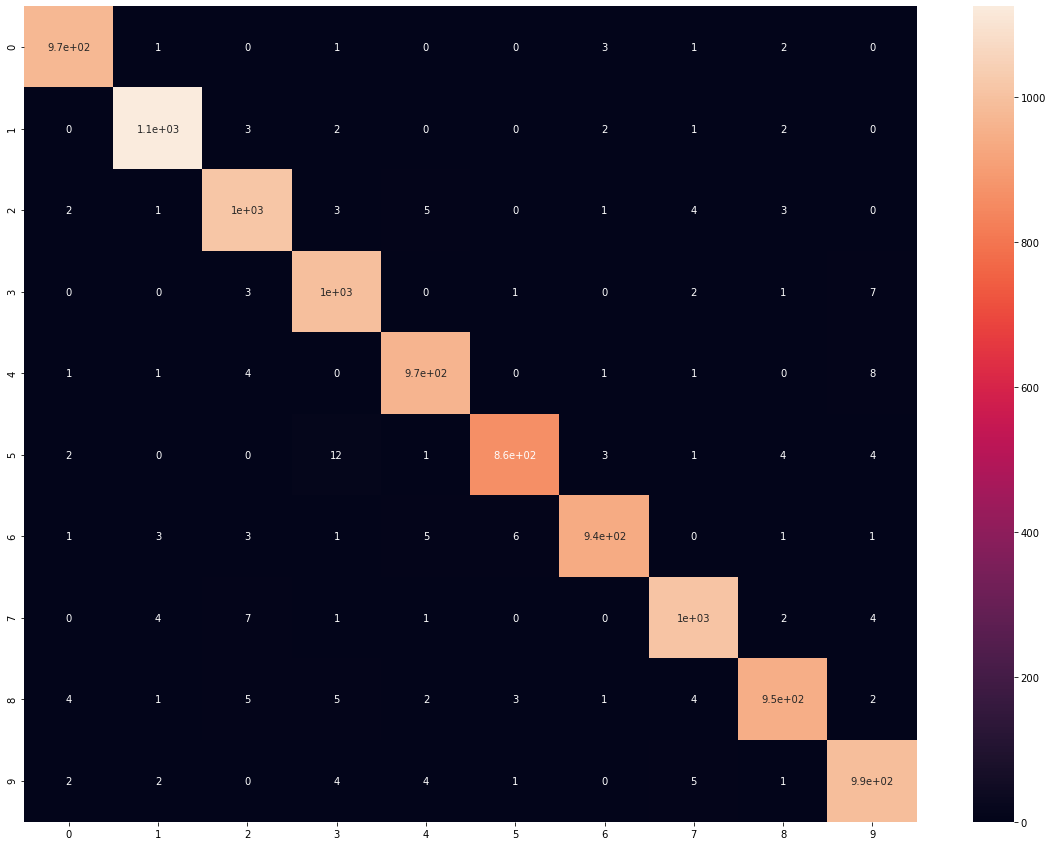

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(cm1, annot = True)

Keras's model was slower but more accurate than the model from scratch.